#### Discuss Considerations of transforming the raw price delta $\Delta_P$ into percentage or log returns

#### NOT Necessary for an MVP

In [94]:

import logging
from pathlib import Path

import numpy as np
import polars as pl
import pandas as pd
# from decimal import Decimal
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

from typing import Optional


In [95]:

class AvailableDatasets:
    """Available Datasets, returns request ID"""

    FULL_YEAR_2024__CME_JPY_V: str = "GLBX-20251028-HAE9P7SP3U"
    FULL_YEAR_2023__CME_JPY_V: str = "GLBX-20251116-MJ5JKQA9A4"
    FULL_YEAR_2022__CME_JPY_V: str = "GLBX-20251115-DJHUGKSLWB"


In [96]:

# WORKING DIRECTORY
MAIN_DIR = Path("/Users/number6/Projects/Bimini/")

# HISTORICAL DATA
HISTORICAL_DATA = MAIN_DIR / "0_data" / "historical"

# IMPORT PATH
PARQUET_DIR = HISTORICAL_DATA / "parquet"

# EXPORT PATH
EXPORT_DIR = MAIN_DIR / "journal_results"


In [97]:

VB100_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_fb30/1721_Nov_21_25/volumebar/raw/volumebar_raw_consolidated.parquet")

# Data files to glob for processing
VB_DATA_GLOB = pl.scan_parquet(str(VB100_DIR))

vb_lf = (
    VB_DATA_GLOB
    # .filter(
    #     ~pl.col("gap_return"),
    #     ~pl.col("bar_complete"),
    # )
    # # .select([
    # #     "id",
    # #     pl.col("start_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("start_ts_ns"),
    # #     pl.col("end_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("end_ts_ns"),
    # # ])
    # .with_columns([
    #     pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_ts_ns"),
    #     # (pl.col("time_elapsed_ns_mean") / 1e9).alias("time_elapsed_ns_mean"),
    # ])
).collect()

vb_lf_row_len = len(vb_lf)
print(f"Original Row Length: {vb_lf_row_len:2,}")


Original Row Length: 1,098,383


In [98]:
def compare_distributions(returns):

    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Histogram with normal distribution overlay
    ax1 = axes[0]
    ax1.hist(returns, bins=200, density=True, alpha=0.7, edgecolor='black', label='Actual Returns')

    # Fit normal distribution to the data
    mu, sigma = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 100)
    normal_dist = stats.norm.pdf(x, mu, sigma)
    ax1.plot(x, normal_dist, 'r-', linewidth=2, label=f'Normal(μ={mu:.4f}, σ={sigma:.4f})')

    ax1.set_xlabel('Returns')
    ax1.set_ylabel('Density')
    ax1.set_title('Returns Distribution vs Normal Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Q-Q plot
    ax2 = axes[1]
    stats.probplot(returns, dist="norm", plot=ax2)
    ax2.set_title('Q-Q Plot')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"Mean: {mu:.6f}")
    print(f"Std Dev: {sigma:.6f}")
    print(f"Skewness: {stats.skew(returns):.4f}")
    print(f"Kurtosis: {stats.kurtosis(returns):.4f}")
    print(f"Jarque-Bera test: statistic={stats.jarque_bera(returns)[0]:.4f}, p-value={stats.jarque_bera(returns)[1]:.4f}")



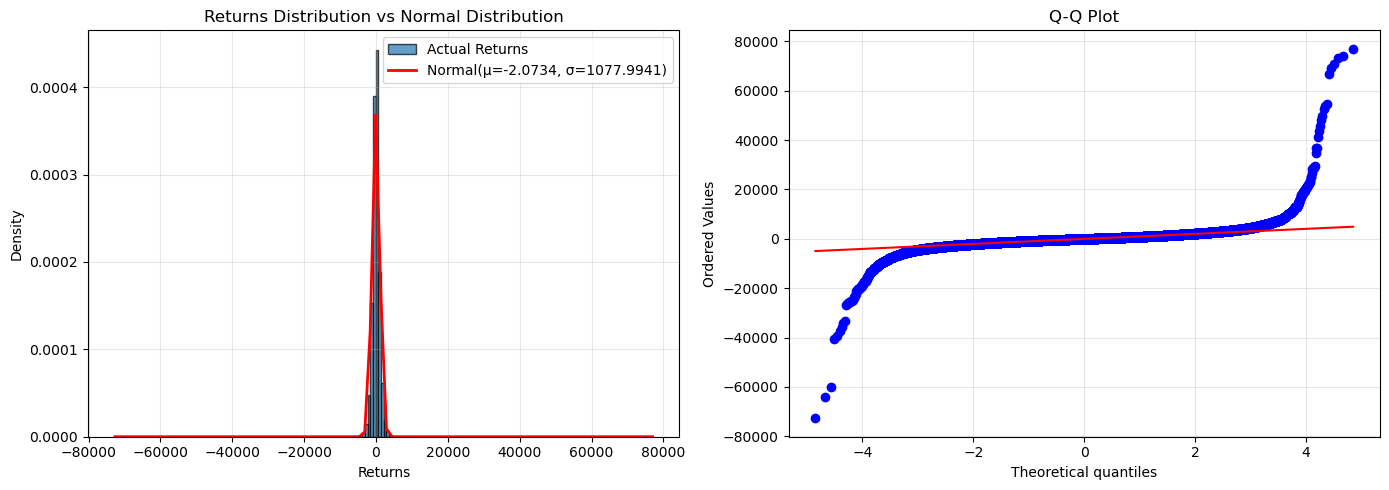

Mean: -2.073359
Std Dev: 1077.994082
Skewness: 1.5958
Kurtosis: 207.5267
Jarque-Bera test: statistic=1971481406.6017, p-value=0.0000


In [99]:
# Extract returns column (assuming it's already calculated)
vb_returns = vb_lf["delta_passive_midprice"].drop_nulls().to_numpy()

compare_distributions(vb_returns)

### Attempt to Clean Up Data

In [100]:
filtered_vb_lf = (
    VB_DATA_GLOB
    .filter(

        ~pl.col("gap_return") &
        pl.col("bar_complete") &
        ~pl.col("contract_roll") &
        # 100% imbalance and 0 price change (oversized order)
        ~((pl.col("passive_imbalance_signed_ratio") > 0.99) & (pl.col("delta_passive_midprice") == 0)) &
        ~((pl.col("passive_imbalance_signed_ratio") < -0.99) & (pl.col("delta_passive_midprice") == 0)) &
        ~((pl.col("active_imbalance_signed_ratio") > 0.99) & (pl.col("delta_active_midpoint_vwap") == 0)) &
        ~((pl.col("active_imbalance_signed_ratio") < -0.99) & (pl.col("delta_active_midpoint_vwap") == 0))
        
    )
).collect()

filtered_vb_lf_row_len = len(filtered_vb_lf)

print(f"Filtered Row Length: {filtered_vb_lf_row_len:2,}")
print(f"Reduced by: {(vb_lf_row_len - filtered_vb_lf_row_len):2,}")

Filtered Row Length: 1,096,675
Reduced by: 1,708


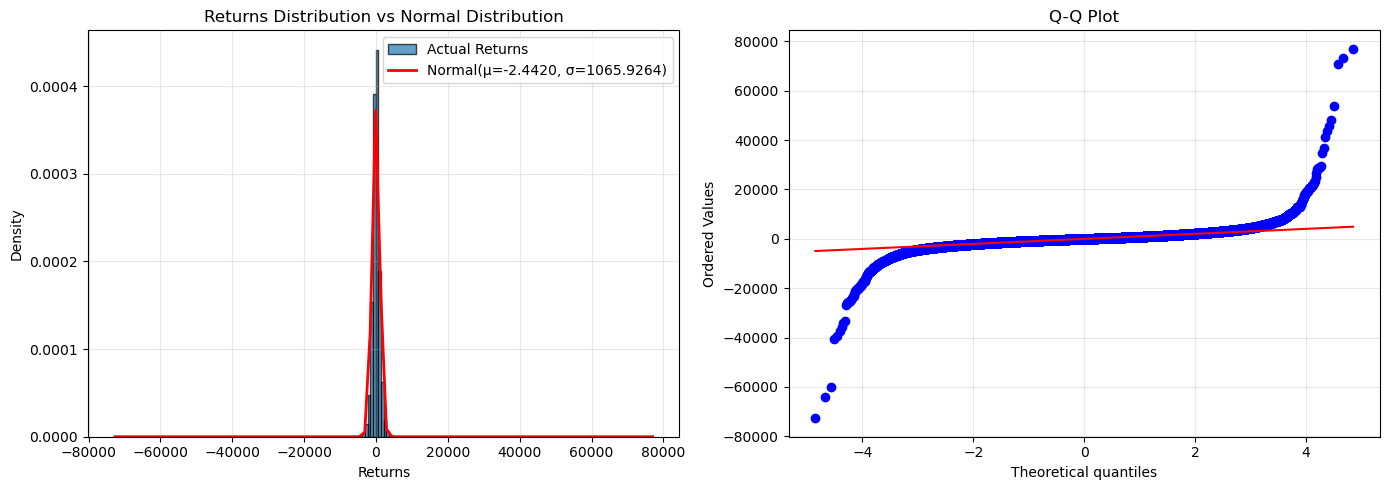

Mean: -2.442027
Std Dev: 1065.926366
Skewness: 0.5273
Kurtosis: 147.5992
Jarque-Bera test: statistic=995535875.1661, p-value=0.0000


In [101]:
# Extract returns column (assuming it's already calculated)
filtered_vb_returns = filtered_vb_lf["delta_passive_midprice"].drop_nulls().to_numpy()

compare_distributions(filtered_vb_returns)

Avg Returns: -2.0733589111319026 | Filtered Avg Returns: -2.4420270362687213 | Diff: 0.3686681251368187
Inverse Avg: 234.78025335273483, Regular Avg: -2.0733589111319026


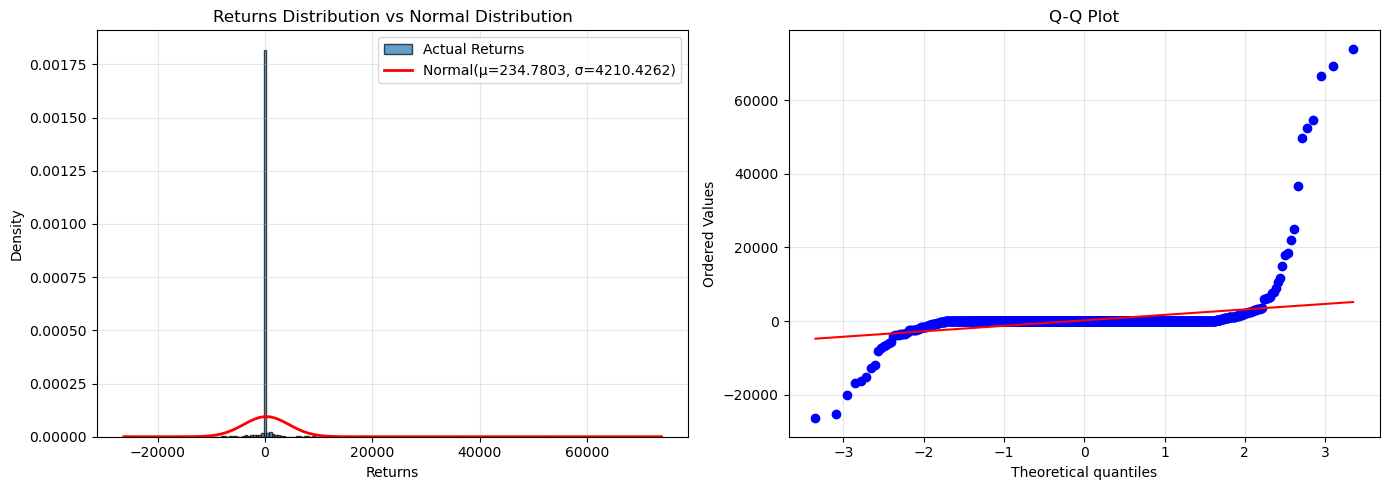

Mean: 234.780253
Std Dev: 4210.426203
Skewness: 11.5784
Kurtosis: 179.0250
Jarque-Bera test: statistic=2317692.2487, p-value=0.0000


In [102]:
inverse_filtered_vb_lf = (
    VB_DATA_GLOB
    .filter(
        pl.col("gap_return") |
        ~pl.col("bar_complete") |
        pl.col("contract_roll") |
        # 100% imbalance and 0 price change, misleading (oversized_order)
        ((pl.col("passive_imbalance_signed_ratio") > 0.99) & (pl.col("delta_passive_midprice") == 0)) |
        ((pl.col("passive_imbalance_signed_ratio") < -0.99) & (pl.col("delta_passive_midprice") == 0)) |
        ((pl.col("active_imbalance_signed_ratio") > 0.99) & (pl.col("delta_active_midpoint_vwap") == 0)) |
        ((pl.col("active_imbalance_signed_ratio") < -0.99) & (pl.col("delta_active_midpoint_vwap") == 0))
    )
    # # .select([
    # #     "id",
    # #     pl.col("start_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("start_ts_ns"),
    # #     pl.col("end_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("end_ts_ns"),
    # # ])
    # .with_columns([
    #     pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_ts_ns"),
    #     # (pl.col("time_elapsed_ns_mean") / 1e9).alias("time_elapsed_ns_mean"),
    # ])
).collect()



avg_vb_returns = np.mean(vb_returns)
avg_filtered_vb_returns = np.mean(filtered_vb_returns)
avg_diff = avg_vb_returns - avg_filtered_vb_returns
print(f"Avg Returns: {avg_vb_returns} | Filtered Avg Returns: {avg_filtered_vb_returns} | Diff: {avg_diff}")

inverse_filtered_vb_returns = inverse_filtered_vb_lf["delta_passive_midprice"].drop_nulls().to_numpy()
avg_inverse_filtered_vb_returns = np.mean(inverse_filtered_vb_returns)
print(f"Inverse Avg: {avg_inverse_filtered_vb_returns}, Regular Avg: {avg_vb_returns}")


compare_distributions(inverse_filtered_vb_returns)

### Export Price Deltas 

In [103]:

export_df = pl.DataFrame({'price_deltas': filtered_vb_returns})

export_df.write_parquet(str(PARQUET_DIR / "price_deltas/filtered_price_deltas.parquet"))

print("Export complete!\n\n", f"{filtered_vb_returns.size:2,} rows\n\n", str(PARQUET_DIR / "price_deltas/filtered_price_deltas.parquet"))

Export complete!

 1,096,675 rows

 /Users/number6/Projects/Bimini/0_data/historical/parquet/price_deltas/filtered_price_deltas.parquet


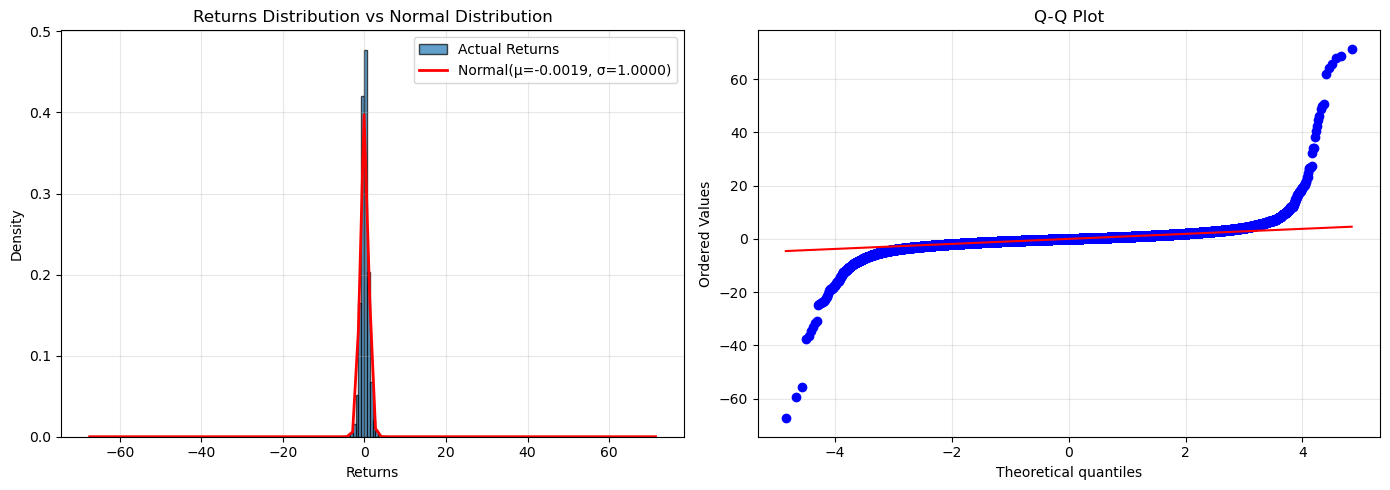

Mean: -0.001923
Std Dev: 1.000000
Skewness: 1.5958
Kurtosis: 207.5267
Jarque-Bera test: statistic=1971481406.6017, p-value=0.0000


In [104]:
# test dividing all values by std...
std_deltas = np.std(vb_returns)
normalized_deltas = vb_returns / std_deltas

compare_distributions(normalized_deltas)

In [105]:
agg_vb_lf = VB_DATA_GLOB.with_columns(
    bucket=pl.int_range(pl.len()) // 25
).group_by("bucket").agg(
    buy_vwap=((pl.col("volume_buy") * pl.col("price_buy_vwap")).sum() / pl.col("volume_buy").sum()) / 1e9,
    sell_vwap=((pl.col("volume_sell") * pl.col("price_sell_vwap")).sum() / pl.col("volume_sell").sum()) / 1e9,
    delta_midpoint_vwap=pl.col("delta_midpoint_vwap").sum(),
).with_columns(
    total_vwap=(pl.col("buy_vwap") + pl.col("sell_vwap")) * 0.5,
    spread=pl.col("buy_vwap") - pl.col("sell_vwap")
).with_columns(
    prev_total_vwap=pl.col("total_vwap").shift(1),
    total_vwap_change=pl.col("total_vwap") - pl.col("total_vwap").shift(1),
    # pct_return=(pl.col("total_vwap") - pl.col("total_vwap").shift(1)) / pl.col("total_vwap").shift(1),
    # log_return=pl.col("total_vwap").log() - pl.col("total_vwap").shift(1).log()
).sort("bucket").drop("bucket").select([
    "delta_midpoint_vwap",
    "buy_vwap",
    "sell_vwap",
    "total_vwap",
    "spread",
    "prev_total_vwap",
    "total_vwap_change",
    # "pct_return",
    # "log_return"
]).collect()


ColumnNotFoundError: unable to find column "volume_buy"; valid columns: ["id", "bar_volume_size", "gap_return", "max_time_gap_ns", "contains_oversized_order", "has_resized", "order_count", "order_splits", "volume_total", "bar_complete", "active_order_count_buy", "active_order_count_sell", "active_order_count_none", "active_volume_buy", "active_volume_sell", "active_volume_none", "active_imbalance_signed", "active_imbalance_abs", "active_imbalance_signed_ratio", "active_imbalance_abs_ratio", "active_imbalance_buy_ratio", "active_imbalance_signed_ratio_atanh", "active_imbalance_buy_ratio_logit", "active_imbalance_abs_ratio_logit", "active_buy_vwap", "active_sell_vwap", "active_none_vwap", "active_spread_vwap", "active_midpoint_vwap", "active_mid_imbalance_weighted", "active_mid_flow_weighted", "active_mid_aggressor_weighted", "active_buy_price_min", "active_buy_price_max", "active_buy_price_range", "active_sell_price_min", "active_sell_price_max", "active_sell_price_range", "active_none_

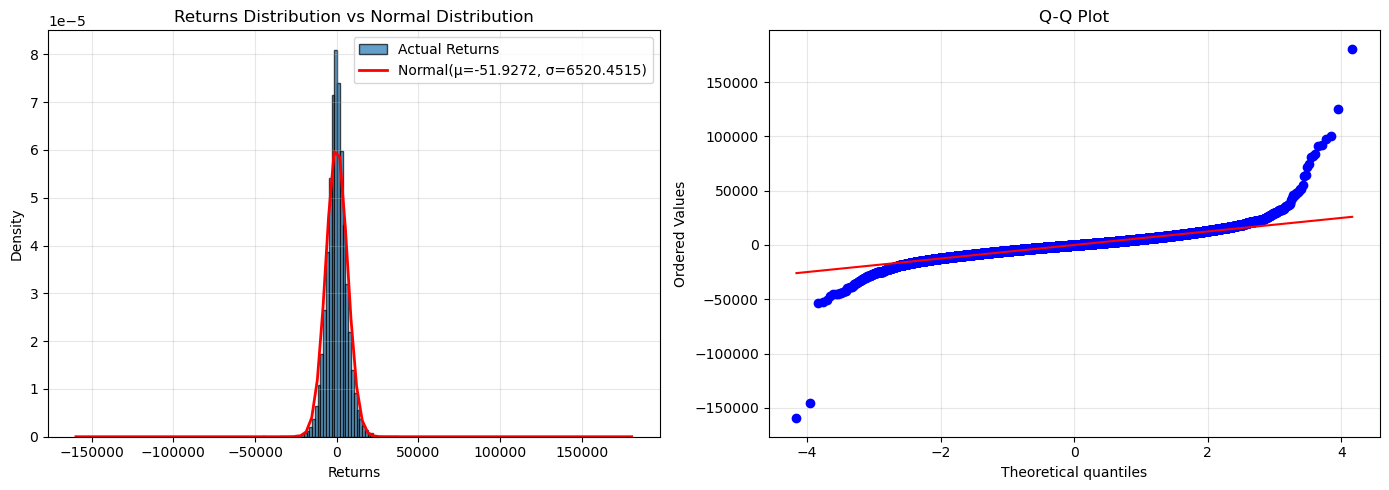

Mean: -51.927222
Std Dev: 6520.451532
Skewness: 0.6770
Kurtosis: 40.2045
Jarque-Bera test: statistic=2957051.1174, p-value=0.0000


In [ ]:
# Extract returns column (assuming it's already calculated)
agg_vb_returns = agg_vb_lf["delta_midpoint_vwap"].drop_nulls().to_numpy()

compare_distributions(agg_vb_returns)

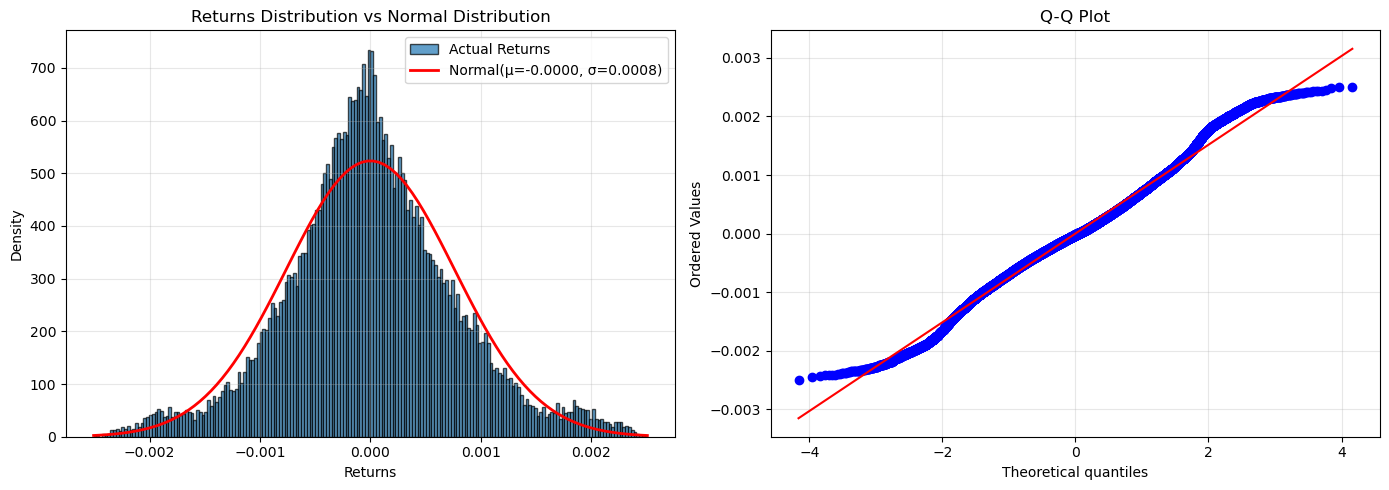

Mean: -0.000000
Std Dev: 0.000762
Skewness: 0.1163
Kurtosis: 0.6060
Jarque-Bera test: statistic=769.9210, p-value=0.0000


In [ ]:
# Extract returns column (assuming it's already calculated)
agg_vb_returns_calculated = agg_vb_lf["total_vwap_change"].drop_nulls().to_numpy()

compare_distributions(agg_vb_returns_calculated)

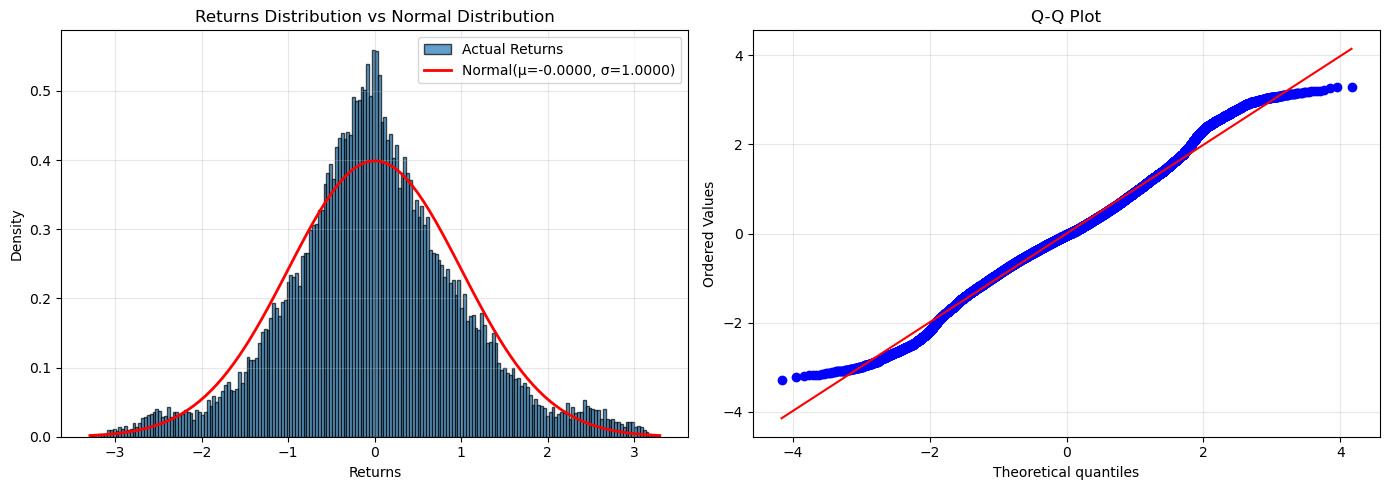

Mean: -0.000024
Std Dev: 1.000000
Skewness: 0.1163
Kurtosis: 0.6060
Jarque-Bera test: statistic=769.9210, p-value=0.0000


In [ ]:
# test dividing all values by std...
std_deltas2 = np.std(agg_vb_returns_calculated)
normalized_deltas2 = agg_vb_returns_calculated / std_deltas2

compare_distributions(normalized_deltas2)

In [ ]:
# Filter NaN values in query

In [ ]:
# get polars data (we already have this query in distribution analysis...)

#### (Once the first-run of BVC is generated)

##### Winsorize returns data to handle (Oversized Orders / Block Trades) bug
- Oversized orders are treated as "Once and Done"
- i.e. if the order_size = 5 * volume_bar_size
    - The first order will show the price jump
    - The subsequent orders will show 100% imbalance and NO price change
    - This will mislead the dataset
        - BUT the ReturnsDistribution should be fine...?
        - It only looks at how often raw price deltas occur (empirically)
        - So it will only see a few more (artificial) 0 price deltas
        - Shouldn't really affect the dataset

- Perhaps this only matters in model training i.e. "100% imbalance yet no price change"
- Solution would be to: winsorize rows with "100% imbalance and 0% price change"



In [ ]:
"""remove top and bottom 1% i.e. winzorize? OR does this need to be done at the DATA_PROCESSING level"""